## Logistic regression Model (Tensorflow: SGD Optimiser version) using all available features


### Part 1

####  1.1 Importing the necessary libraries and constant variables


If using google colab, use the following code:


In [1]:
run_in_colab = False

In [2]:
def if_colab_run_this():
    import os
    # Clone the repo into Colab's working directory
    !git clone https://github.com/wip-0/ds207_final_project.git /content/ds207_final_project

    # Install optuna in google colab
    !pip install optuna

    # Add project root to Python path so 'src' is importable
    import sys
    sys.path.insert(0, '/content/ds207_final_project')
    # Verify src exists
    from pathlib import Path
    src_path = Path('/content/ds207_final_project/src')
    print(f"src exists: {src_path.exists()}")
    print("src contents:")
    for item in sorted(src_path.iterdir()):
        print(f"  {item.name}")

# apply the function only if you run it in google colab:
if run_in_colab:
    if_colab_run_this()

In [3]:
import os
import tempfile
import json
from pathlib import Path

# custom imports
from src.utils.data_fetch import DataLoader
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix

# for implementing neural network
import tensorflow as tf
from tensorflow import keras
import random
import re

# other essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# for data preprocessing
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

# various scoring metrics
from sklearn.metrics import (classification_report, accuracy_score,
                             recall_score, precision_score,
                             f1_score, roc_auc_score, average_precision_score)

# for hyperparameter tuning
import optuna
from functools import partial


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start).resolve()
    for path in [current, *current.parents]:
        if (path / '.paths').exists() or (path / 'pyproject.toml').exists():
            return path
    return current


# export path for the final model:
project_root = find_project_root()
export_dir = project_root / 'models' / 'logistic_regression_tf_SGD'
export_dir.mkdir(parents=True, exist_ok=True)

SEED = 1234


/Users/vtsoumpris/PycharmProjects/ds207_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


####  1.2 Loading the data

For quickly loading data:

In [4]:
def import_data(version='final_onehot', access= 'remote'):
    """
    Import train, validation, and test datasets.

    Parameters:
    - version: str, one of 'interim', 'final_raw', 'final_label', 'final_onehot'
    - access: str, 'local' or 'remote'
    """

    version_map = {
        'interim': 'interim/split_kf_group_stratified',
        'final_raw': 'final_processed/base_kf/raw',
        'final_label': 'final_processed/base_kf/label',
        'final_onehot': 'final_processed/base_kf/onehot'
    }

    if access == 'remote':
        # Use the DataLoader which handles remote URLs properly
        loader = DataLoader()
        return loader.fetch_data(version=version)

    elif access == 'local':
        import pandas as pd
        from pathlib import Path

        # Find project root (where .paths file is located)
        current = Path.cwd()
        while not (current / '.paths').exists():
            if current.parent == current:
                raise FileNotFoundError("Could not find project root with .paths file")
            current = current.parent

        project_root = current
        data_dir = project_root / 'data' / version_map[version]

        # Check if directory exists
        if not data_dir.exists():
            raise FileNotFoundError(
                f"Data directory does not exist: {data_dir}\n"
                f"Please use access='remote' to download from GitHub, "
                f"or ensure local data is available."
            )

        # Read the CSV files
        df_Xtrain = pd.read_csv(data_dir / 'X_train_mini.csv', low_memory=False)
        df_Xval = pd.read_csv(data_dir / 'X_val.csv', low_memory=False)
        df_Xtest = pd.read_csv(data_dir / 'X_test.csv', low_memory=False)
        df_ytrain = pd.read_csv(data_dir / 'y_train_mini.csv', low_memory=False)
        df_yval = pd.read_csv(data_dir / 'y_val.csv', low_memory=False)
        df_ytest = pd.read_csv(data_dir / 'y_test.csv', low_memory=False)

        print(f"Data imported successfully from: {data_dir}")
        return df_Xtrain, df_Xval, df_Xtest, df_ytrain, df_yval, df_ytest

    else:
        raise ValueError(f"Invalid access type: {access}."
                           f"Choose 'local' or 'remote'")

**Loading the data:**

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = import_data(version='final_onehot',
                                                            access='remote')

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/onehot/y_test.csv 
Data imported succesfully from paths


In [6]:
X_train.head()

,pipeline_onehot__max_glu_serum_>200,pipeline_onehot__max_glu_serum_>300,pipeline_onehot__max_glu_serum_Norm,pipeline_onehot__max_glu_serum_Unknown,pipeline_onehot__A1Cresult_>7,pipeline_onehot__A1Cresult_>8,pipeline_onehot__A1Cresult_Norm,pipeline_onehot__A1Cresult_Unknown,pipeline_onehot__race_AfricanAmerican,pipeline_onehot__race_Asian,...,pipeline_prescript__metformin-pioglitazone_Up,pipeline_prescript__metformin-pioglitazone_Down,pipeline_standard__time_in_hospital,pipeline_standard__num_lab_procedures,pipeline_standard__num_procedures,pipeline_standard__num_medications,pipeline_standard__number_outpatient,pipeline_standard__number_emergency,pipeline_standard__number_inpatient,pipeline_standard__number_diagnoses
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,-0.470473,0.823161,-0.782086,0.245909,-0.291189,-0.199957,-0.500694,0.820593
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,-0.805790,-1.629771,2.148426,-0.369472,1.244021,-0.199957,0.285436,-0.729658
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,-0.805790,0.056620,-0.195984,-0.000244,-0.291189,-0.199957,-0.500694,-0.212908
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,-1.141107,0.414339,-0.782086,-0.984853,-0.291189,-0.199957,-0.500694,-1.246408
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,-0.470473,-0.607716,2.734529,-0.000244,-0.291189,-0.199957,-0.500694,0.820593


In [7]:
y_train.head()

,readmitted
0,1
1,0
2,0
3,0
4,1


####  1.3 Preprocessing and selecting specific features

The 'final one-hot' version of the data includes all categorical features one-hot encoded and numeric features standardised. For this model, no additional data preprocessing will be implemented.

In [8]:
def target_to_numpy(y):
    if isinstance(y, pd.DataFrame):
        values = y.iloc[:, 0].copy()
    elif isinstance(y, pd.Series):
        values = y.copy()
    else:
        values = pd.Series(np.asarray(y).ravel())

    values = values.replace({'NO': 0, '>30': 1, '<30': 1})
    values = pd.to_numeric(values, errors='raise')

    return values.astype('int32').to_numpy().ravel()

#### Applying the functions to the train, validation, and test sets


#### Part 2 - Initial Model Creation

**2.1** Creating the model using Keras Functional API with trainable categorical embeddings:


For plotting the loss/auc/recall curves on training and validation sets:

In [9]:
def plot_model_report(history, metrics= None):
    """
    Plot training and validation curves for specified metrics from model training history.
    Examples:
    # Plot single metric
    plot_model_report(history, 'roc_auc')
    # Plot multiple metrics
    plot_model_report(history, ['loss', 'roc_auc', 'recall'])
    # Plot all available metrics (auto-detect)
    plot_model_report(history)
    """

    # Auto-detect metrics if not specified
    if metrics is None:
        # Find all metrics that have validation counterparts
        train_metrics = [k for k in history.keys() if not k.startswith('val_')]
        metrics = [m for m in train_metrics if f'val_{m}' in history.keys()]

        if not metrics:
            raise ValueError("No metrics with validation counterparts found in history")

    # Convert single metric to list
    if isinstance(metrics, str):
        metrics = [metrics]
    # Validate that all metrics exist
    for metric in metrics:
        if metric not in history:
            raise ValueError(f"Metric '{metric}' not found in history. "
                           f"Available metrics: {list(history.keys())}")
        if f'val_{metric}' not in history:
            raise ValueError(f"Validation metric 'val_{metric}' not found in history.")

    # Determine number of subplots
    n_metrics = len(metrics)
    n_cols = min(3, n_metrics)  # Max 3 columns
    n_rows = (n_metrics + n_cols - 1) // n_cols  # Ceiling division
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    # Handle single subplot case
    if n_metrics == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_metrics > 1 else [axes]

    # Plot each metric
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        # Create epoch range
        epochs = np.arange(1, len(history[metric]) + 1)
        # Plot training and validation
        ax.plot(epochs, history[metric], lw=2, color='blue', label='Train')
        ax.plot(epochs, history[f'val_{metric}'], lw=2, color='indianred', label='Validation')
        # Formatting
        metric_label = metric.replace('_', ' ').title()
        ax.set_xlabel('Epochs', size=10)
        ax.set_ylabel(metric_label, size=10)
        ax.set_title(f'{metric_label} Plot', fontweight='bold')
        ax.legend(fontsize= 10)
        ax.set_xticks(epochs, minor= True)
        ax.set_xlim(1, len(history[metric]))
        ax.grid(True, alpha=0.3)

    # Hide extra subplots if any
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

Extracting feature dimensions, dropping ID columns, creating the suitable input format and setting the bias init value:


In [10]:
# creating the input feature shape:
id_cols = ['pipeline_raw__encounter_id']

# drop the ID columns from the dataframes
train_inputs = X_train.drop(columns= id_cols)
val_inputs = X_val.drop(columns= id_cols)
test_inputs = X_test.drop(columns= id_cols)

# transform the y sets to numpy format
y_train_array = target_to_numpy(y_train)
y_val_array = target_to_numpy(y_val)
y_test_array = target_to_numpy(y_test)

features_shape = train_inputs.shape[1]

# positive rate in y-train (mean)
pos_rate = y_train_array.mean()
# bias initial value
#bias_init = np.log(pos_rate / (1 - pos_rate))

print(pos_rate)
print(features_shape)

0.47126918882644075
190


In [11]:
def create_model(num_features = features_shape, lr= 1e-4):
 """Build a TF logistic regression model using Keras.

  Args:
    num_features: The number of input features.
    learning_rate: The desired learning rate for Adam.

  Returns:
    model: A tf.keras model (graph).
  """

 tf.random.set_seed(SEED)
 np.random.seed(SEED)
 random.seed(SEED)
 tf.keras.utils.set_random_seed(SEED)
 tf.keras.backend.clear_session()

 # Build a model using keras.Sequential. While this is intended for neural
 # networks (which may have multiple layers), we want just a single layer for
 # binary logistic regression.
 model = keras.Sequential([
        keras.Input(shape=(num_features,)),
        keras.layers.Dense(
            1,
            activation='sigmoid',
            use_bias= True,
            kernel_initializer= 'zeros',
            bias_initializer= keras.initializers.zeros(),
            kernel_regularizer= keras.regularizers.l2(1e-4),
        )
 ])

 # compiling the model using Adam Optimiser
 model.compile(
        optimizer= keras.optimizers.SGD(learning_rate= lr, nesterov= True),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(curve='ROC', name='roc_auc'),
            keras.metrics.AUC(curve='PR', name='pr_auc'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.Precision(name='precision'),
        ],
 )
 return model

In [12]:
def build_model(num_features = features_shape, lr= 1e-4,
                positive_class_weight= 1.0,
                epochs= 100,
                batch_size= 256,
                train_inputs= train_inputs,
                y_train_array = y_train_array,
                val_inputs= val_inputs,
                y_val_array= y_val_array
                ):
    """
    Builds and trains a logistic regression model.
    """

    # create model with embeddings and dense hidden layers
    model = create_model(num_features, lr= lr)

    # fit the model and create a history
    history = model.fit(
        train_inputs, y_train_array,
        validation_data= (val_inputs, y_val_array),
        epochs= epochs,
        batch_size= batch_size,
        class_weight= {0: 1.0, 1: positive_class_weight},
    )

    return model, history

In [13]:
init_model, init_history = build_model(epochs = 200)

Epoch 1/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6927 - pr_auc: 0.4990 - precision: 0.6156 - recall: 0.0469 - roc_auc: 0.5409 - val_loss: 0.6922 - val_pr_auc: 0.5482 - val_precision: 0.8848 - val_recall: 0.0156 - val_roc_auc: 0.5457
Epoch 2/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 0.6918 - pr_auc: 0.5451 - precision: 0.8844 - recall: 0.0180 - roc_auc: 0.5629 - val_loss: 0.6913 - val_pr_auc: 0.5829 - val_precision: 0.8901 - val_recall: 0.0182 - val_roc_auc: 0.6128
Epoch 3/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - loss: 0.6910 - pr_auc: 0.5858 - precision: 0.8827 - recall: 0.0214 - roc_auc: 0.6020 - val_loss: 0.6905 - val_pr_auc: 0.6025 - val_precision: 0.8826 - val_recall: 0.0217 - val_roc_auc: 0.6212
Epoch 4/200
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step - loss: 0.6902 - pr_auc: 0.5987 - precision: 0.8723 - recall: 0.0248 - roc_auc: 0.6193 - val_loss: 0.6898 - val_pr_auc: 0.6113 - val_precision: 0.8830 - val_recall: 0.0250 - val_roc_auc: 0.6322
Epoch 

In [14]:
init_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │           191 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (776.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

**2.2** Plotting training and validation loss, AUC, recall curves:

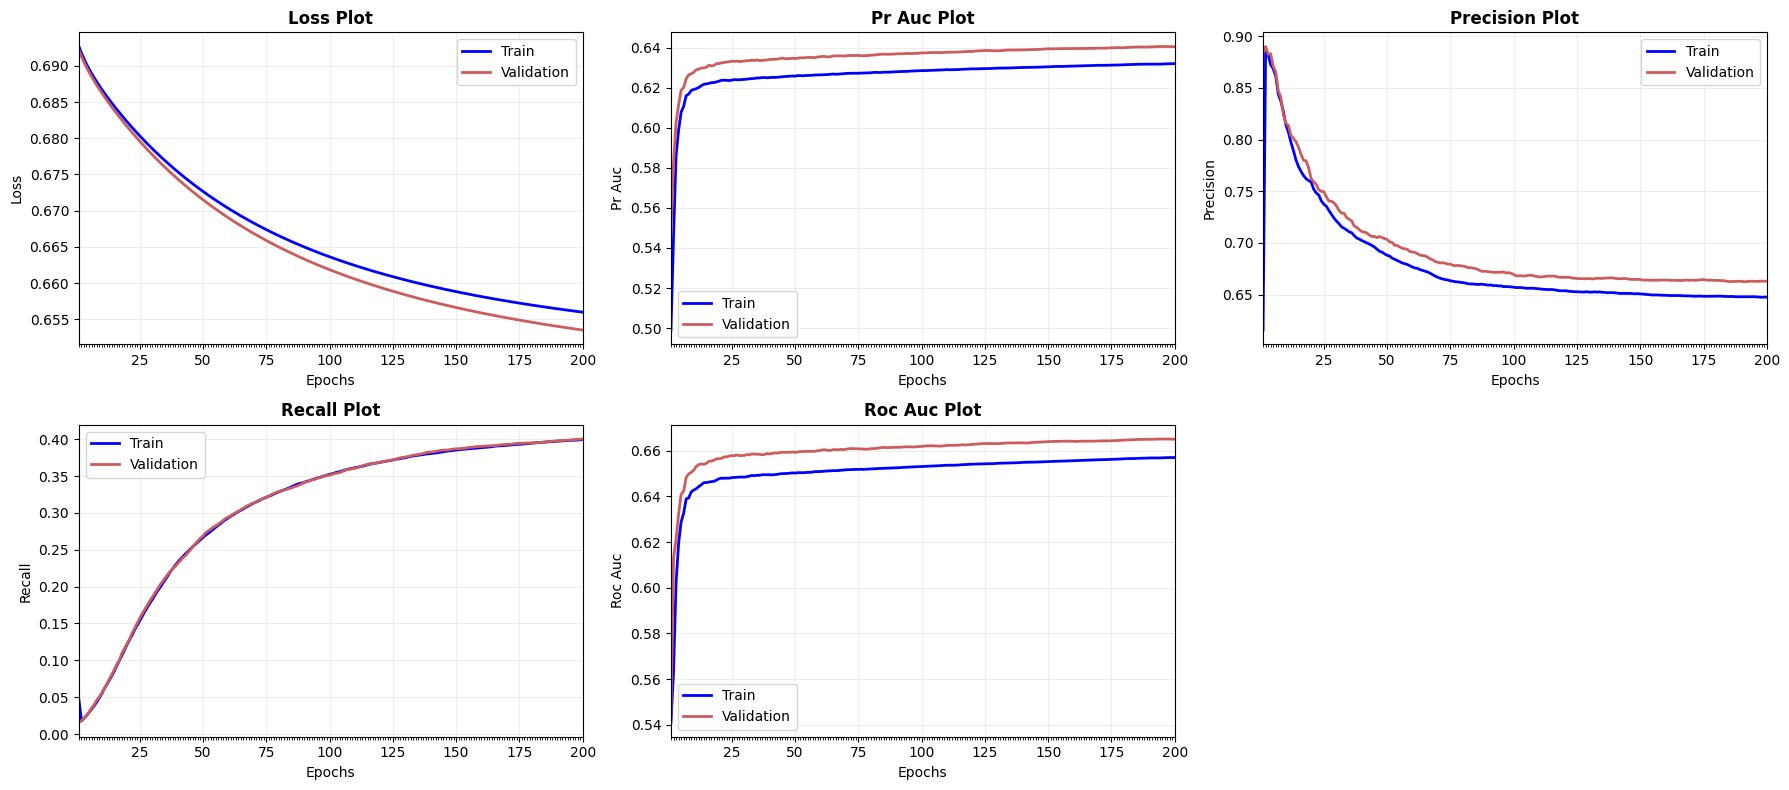

In [15]:
plot_model_report(history= init_history.history)

#### Part 3: Fine-tuning model of using Optuna

**3.1** Defining trainable-embedding model architecture to be optimised:


In [16]:
def build_model_optuna(trial):
    # build model suitable for optuna trial
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    learning_rate = trial.suggest_categorical('learning_rate', [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1])
    model = create_model(num_features = features_shape, lr= learning_rate,)

    return model

**3.2** Defining fitting function (more hyper-parameters to be optimised):


In [17]:
def fit_model_optuna(trial,
                     model,
                     batch_size,
                     positive_class_weight,
                     epochs= 200,
                     verbose= 1,
                     train_inputs= train_inputs,
                     y_train_array = y_train_array,
                     val_inputs= val_inputs,
                     y_val_array= y_val_array
                     ):

    history = model.fit(
        train_inputs, y_train_array,
        validation_data=(val_inputs, y_val_array),
        epochs= epochs,
        batch_size= batch_size,
        class_weight= {0: 1.0, 1: positive_class_weight},
        verbose= verbose,
    )

    return history

**3.3** Defining the objective function. The study optimizes validation PR AUC directly.


In [18]:
def objective_fn(trial):
    """
    Defines the objective function for an Optuna optimization trial. The function configures the
    model and its parameters, evaluates its performance, and stores the best results for analysis.
    """
    batch_size = trial.suggest_categorical('batch_size', [64 ,128, 256, 512])
    positive_class_weight = trial.suggest_float('positive_class_weight', 1.0, 1.4, step= 0.05)

    # build and fit the model
    model = build_model_optuna(trial)
    history = fit_model_optuna(
        trial,
        model,
        batch_size= batch_size,
        positive_class_weight= positive_class_weight,
    )

    # the objective is to maximize the validation PR-AUC
    val_pr_auc = history.history['val_pr_auc']
    best_epoch_idx = int(np.argmax(val_pr_auc))

    # set attributes for the Optuna trial
    trial.set_user_attr('best_epoch', best_epoch_idx + 1)
    trial.set_user_attr('best_val_pr_auc', float(history.history['val_pr_auc'][best_epoch_idx]))
    trial.set_user_attr('best_val_roc_auc', float(history.history['val_roc_auc'][best_epoch_idx]))
    trial.set_user_attr('best_val_recall', float(history.history['val_recall'][best_epoch_idx]))
    trial.set_user_attr('best_val_precision', float(history.history['val_precision'][best_epoch_idx]))

    return float(history.history['val_pr_auc'][best_epoch_idx])

**3.4** Running the optimization (study):

In [19]:
def extract_best_params(study):
    """
    Extract the best parameters from a completed Optuna study.
    """
    completed_trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
    ]
    if not completed_trials:
        raise ValueError('No completed Optuna trials available. Run study.optimize first.')

    return study.best_params

In [20]:
# to load the existing study
# (saved under the model folder as a SQLite db format)
load_existing_study = True

###### ###### ######
storage_path = f"sqlite:///{export_dir / 'optuna_study.db'}"
num_trials = 15
sec_timeout = 3600

In [21]:
# create study (or load an existing one)
study = optuna.create_study(
    study_name='logistic_regression_allfeats_optuna',
    direction='maximize',
    storage= storage_path,
    load_if_exists= True,
)

# checking if the study
# has already been completed
completed_trials = [
    trial for trial in study.trials
    if trial.state == optuna.trial.TrialState.COMPLETE
]

# Run optimization unless explicitly loading an existing study that already has results.
if (not load_existing_study) or (len(completed_trials) == 0):
    study.optimize( func= objective_fn,
                    n_trials= num_trials,
                    timeout= sec_timeout
                   )

[I 2026-07-28 10:16:08,439] Using an existing study with name 'logistic_regression_allfeats_optuna' instead of creating a new one.


In [22]:
# extracting best parameters from the study
best_params = extract_best_params(study)
best_params

{'batch_size': 512, 'positive_class_weight': 1.4, 'learning_rate': 0.01}

**3.5** Creating the final fine-tuned model:

In [23]:
def build_model_fine_tuned(best_parameters= best_params,
                           fit_model= True,
                           epochs= 200,
                           verbose= 1,
                           num_features = features_shape,
                           train_inputs= train_inputs,
                           y_train_array = y_train_array,
                           val_inputs= val_inputs,
                           y_val_array= y_val_array):
    # setting the seed for reproducibility
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    tf.keras.utils.set_random_seed(SEED)
    tf.keras.backend.clear_session()

    model = create_model(num_features = num_features,
                         lr= best_parameters['learning_rate'])

    history = None
    if fit_model:
        history = model.fit(
            train_inputs, y_train_array,
            validation_data= (val_inputs, y_val_array),
            epochs= epochs,
            batch_size= best_parameters['batch_size'],
            class_weight= {0: 1.0, 1: best_parameters['positive_class_weight']},
            verbose=verbose
        )
    return model, history

**Getting the structure of the model without fitting it first**:

In [24]:
model_finetuned, _ = build_model_fine_tuned(
    best_parameters=best_params,
    fit_model= False,
    epochs= 50,
    verbose= 1
)
model_finetuned.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │           191 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191 (764.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 0 (0.00 B)

**Fitting the fine-tuned model**:

In [25]:
model_finetuned, history_fine_tuned = build_model_fine_tuned(
    best_parameters= best_params,
    fit_model= True,
    epochs= 50,
    verbose= 1
)

Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8028 - pr_auc: 0.6010 - precision: 0.4755 - recall: 0.9802 - roc_auc: 0.6215 - val_loss: 0.6817 - val_pr_auc: 0.6354 - val_precision: 0.4987 - val_recall: 0.9369 - val_roc_auc: 0.6604
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - loss: 0.7862 - pr_auc: 0.6266 - precision: 0.5092 - recall: 0.8933 - roc_auc: 0.6512 - val_loss: 0.6718 - val_pr_auc: 0.6380 - val_precision: 0.5282 - val_recall: 0.8423 - val_roc_auc: 0.6629
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - loss: 0.7789 - pr_auc: 0.6296 - precision: 0.5261 - recall: 0.8274 - roc_auc: 0.6544 - val_loss: 0.6667 - val_pr_auc: 0.6400 - val_precision: 0.5397 - val_recall: 0.7999 - val_roc_auc: 0.6648
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 0.7750 - pr_auc: 0.6316 - precision: 0.5348 - recall: 0.7965 - roc_auc: 0.6567 - val_loss: 0.6638 - val_pr_auc: 0.6414 - val_precision: 0.5462 - val_recall: 0.7754 - val_roc_auc: 0.6662
Epoch 5/50

**Plotting AUC, Recall and Loss of the fine-tuned model (train & validation set)**:

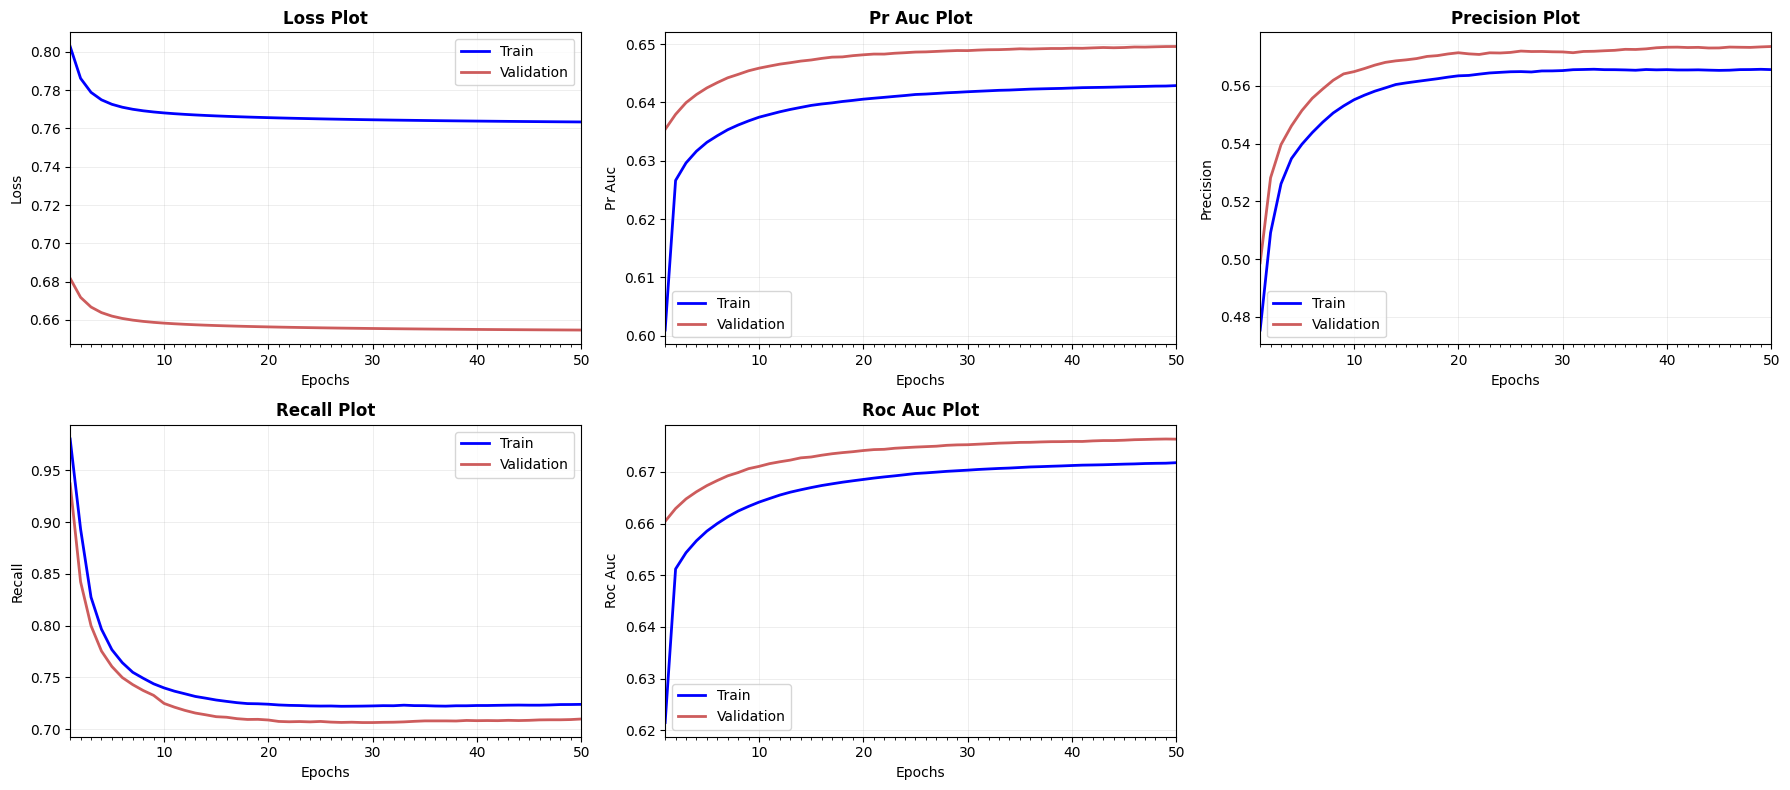

In [26]:
plot_model_report(history= history_fine_tuned.history)

Evaluation using the default threshold of 0.5:

1863/1863 ━━━━━━━━━━━━━━━━━━━━ 0s 175us/step
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 169us/step
 validation threshold: 0.500
Train Set Report:
              precision    recall  f1-score   support

           0       0.67      0.52      0.58     31515
           1       0.57      0.72      0.63     28090

    accuracy                           0.61     59605
   macro avg       0.62      0.62      0.61     59605
weighted avg       0.62      0.61      0.61     59605

Validation Set Report:
              precision    recall  f1-score   support

           0       0.67      0.53      0.59     10506
           1       0.57      0.71      0.63      9363

    accuracy                           0.61     19869
   macro avg       0.62      0.62      0.61     19869
weighted avg       0.63      0.61      0.61     19869



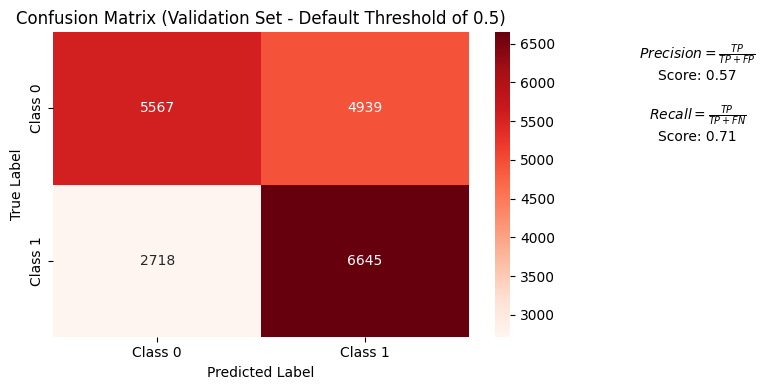

In [27]:
# after training the model
ypred_train_proba = model_finetuned.predict(train_inputs).ravel()
ypred_val_proba = model_finetuned.predict(val_inputs).ravel()

default_threshold = 0.5

print(f' validation threshold: {default_threshold:.3f}')

# converting to binary predictions
ypred_train_binary = (ypred_train_proba >= default_threshold).astype(int).flatten()
ypred_val_binary = (ypred_val_proba >= default_threshold).astype(int).flatten()

# Now evaluate using evaluation function
print('Train Set Report:')
recall_tr, precision_tr, f1_tr, acc_tr, cl_report_tr = \
    evaluate_predictions(true_values= y_train,
                         predictions= ypred_train_binary,
                         print_class_report=True)
print('Validation Set Report:')
recall_vl, precision_vl, f1_vl, acc_vl, cl_report_vl = \
    evaluate_predictions(true_values= y_val,
                         predictions= ypred_val_binary,
                         print_class_report=True)

# Plot confusion matrix (validation set)
scores = plot_confusion_matrix(y_true=y_val['readmitted'],
                               y_pred= ypred_val_binary,
                               fig_size= (8, 4),
                               title='Confusion Matrix (Validation Set - Default Threshold of 0.5)',
                               colour_map='Reds')

### Part 4: Choosing a validation-set threshold and converting predictions to binary


In [28]:
def find_best_threshold(y_true, y_proba, metric= 'f1', min_precision= None):
    """
    Finds the optimal probability threshold for binary classification based on a given metric,
    while optionally enforcing a minimum precision constraint.

    Given the true binary labels and the predicted probabilities, this function evaluates various
    threshold values and calculates their corresponding performance metrics (precision, recall, F1-score,
    accuracy). It allows the user to specify whether the optimization should prioritize a particular metric,
    such as 'f1', 'recall', or 'precision'. Optionally, a minimum precision threshold can be enforced,
    which will exclude thresholds that do not satisfy the precision requirement.

    :param y_true: Array-like of shape (n_samples,) containing the ground-truth binary labels. Input data is
        expected to be in binary {0, 1} format.
    :param y_proba: Array-like of shape (n_samples,) containing the predicted probabilities for the positive
        class (class 1). Probabilities should be in the range [0.0, 1.0].
    :param metric: Optional string value specifying the performance metric to optimize. Default is 'f1'.
        Allowed values include 'f1', 'precision', 'recall', and 'pr_auc'.
        PR-AUC is calculated from the predicted probabilities and is therefore threshold-independent;
        when metric='pr_auc', F1-score is used as the tie-breaker for selecting a threshold.
    :param min_precision: Optional float value specifying the minimum precision constraint. If provided,
        thresholds that result in a precision below this value will be penalized by assigning a negative
        infinity score.

    :return: A tuple containing two elements:
        - Best threshold value (float) optimizing the specified metric.
        - A pandas DataFrame containing detailed performance metrics (threshold, precision, recall,
          F1-score, accuracy, and score) for all evaluated thresholds across the range [0.05, 0.95].
    """
    y_true = np.asarray(y_true).ravel()
    y_proba = np.asarray(y_proba).ravel()
    valid_metrics = {'f1', 'precision', 'recall', 'pr_auc'}
    if metric not in valid_metrics:
        raise ValueError(f"metric must be one of {sorted(valid_metrics)}")

    # average_precision_score summarizes a precision-recall curve
    # as the weighted mean of precisions achieved at each threshold,
    # with the increase in recall from the previous threshold used as the weight
    pr_auc = average_precision_score(y_true, y_proba)
    thresholds = np.linspace(0.05, 0.95, 181)

    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division= 0)
        recall = recall_score(y_true, y_pred, zero_division= 0)
        f1 = f1_score(y_true, y_pred, zero_division= 0)
        accuracy = accuracy_score(y_true, y_pred)

        if metric == 'recall':
            score = recall
        elif metric == 'precision':
            score = precision
        elif metric == 'pr_auc':
            score = pr_auc
        else:
            score = f1

        if min_precision is not None and precision < min_precision:
            score = -np.inf

        rows.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'accuracy': accuracy,
            'pr_auc': pr_auc,
            'score': score,
        })

    threshold_results = pd.DataFrame(rows)
    sort_columns = ['score', 'f1_score'] if metric == 'pr_auc' else ['score']
    best_row = threshold_results.sort_values(sort_columns, ascending=False).iloc[0]

    return float(best_row['threshold']), threshold_results

1863/1863 ━━━━━━━━━━━━━━━━━━━━ 0s 194us/step
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 195us/step
Best validation threshold: 0.435


,threshold,precision,recall,f1_score,accuracy,pr_auc,score
77,0.435,0.525323,0.880701,0.658101,0.568775,0.64968,0.658101
76,0.430,0.521543,0.889459,0.657534,0.563390,0.64968,0.657534
78,0.440,0.528309,0.870020,0.657413,0.572701,0.64968,0.657413
73,0.415,0.513163,0.913916,0.657270,0.550858,0.64968,0.657270
74,0.420,0.515836,0.904518,0.656995,0.554935,0.64968,0.656995


              precision    recall  f1-score   support

           0       0.73      0.28      0.40     31515
           1       0.52      0.89      0.66     28090

    accuracy                           0.56     59605
   macro avg       0.63      0.58      0.53     59605
weighted avg       0.63      0.56      0.52     59605

              precision    recall  f1-score   support

           0       0.73      0.29      0.42     10506
           1       0.53      0.88      0.66      9363

    accuracy                           0.57     19869
   macro avg       0.63      0.59      0.54     19869
weighted avg       0.63      0.57      0.53     19869



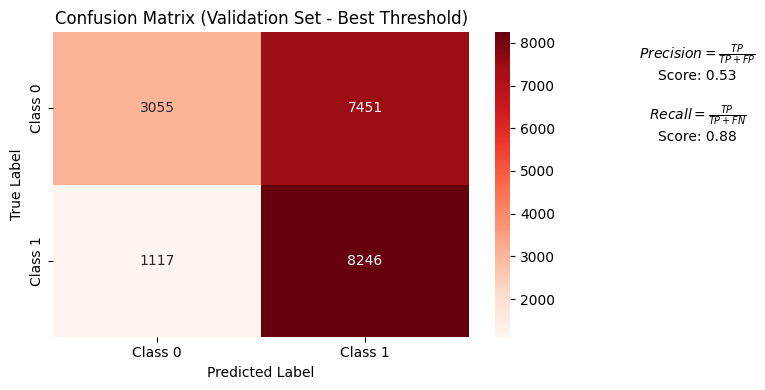

In [29]:
# after training the model
ypred_train_proba = model_finetuned.predict(train_inputs).ravel()
ypred_val_proba = model_finetuned.predict(val_inputs).ravel()

# Select threshold on validation set only.
best_threshold, threshold_results = find_best_threshold(
    y_true= y_val_array,
    y_proba= ypred_val_proba,
    metric='f1'
)

print(f'Best validation threshold: {best_threshold:.3f}')
display(threshold_results.sort_values('score', ascending=False).head())

# converting to binary predictions
ypred_train_binary = (ypred_train_proba >= best_threshold).astype(int).flatten()
ypred_val_binary = (ypred_val_proba >= best_threshold).astype(int).flatten()

# Now evaluate using your evaluation function
recall_tr, precision_tr, f1_tr, acc_tr, cl_report_tr = \
    evaluate_predictions(true_values= y_train,
                         predictions= ypred_train_binary,
                         print_class_report=True)

recall_vl, precision_vl, f1_vl, acc_vl, cl_report_vl = \
    evaluate_predictions(true_values= y_val,
                         predictions= ypred_val_binary,
                         print_class_report= True)

# Plot confusion matrix (validation set)
scores = plot_confusion_matrix(y_true= y_val['readmitted'],
                               y_pred= ypred_val_binary,
                               fig_size= (8, 4),
                               title='Confusion Matrix (Validation Set - Best Threshold)',
                               colour_map='Reds')


### Part 5: Test Set Evaluation

Generating predictions on test data...
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 197us/step
Test set size: 19869 samples
Predictions generated: 19869
Classification threshold before calibration: 0.500
Classification threshold after calibration: 0.435
-------
Classification Report using the default (0.5) threshold:
              precision    recall  f1-score   support

           0       0.67      0.53      0.59     10506
           1       0.57      0.71      0.64      9363

    accuracy                           0.61     19869
   macro avg       0.62      0.62      0.61     19869
weighted avg       0.63      0.61      0.61     19869



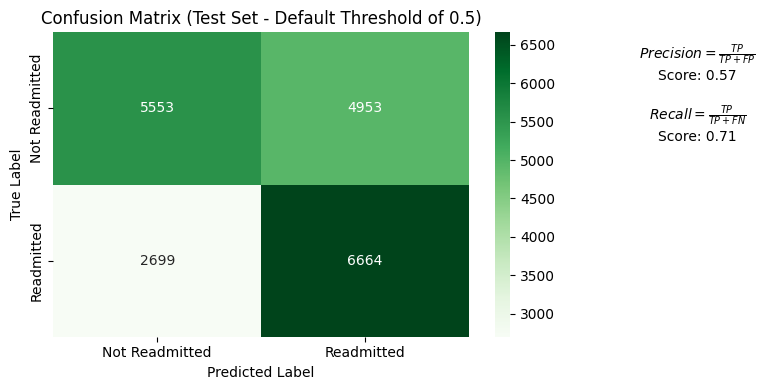

Classification Report using the best threshold:
              precision    recall  f1-score   support

           0       0.74      0.29      0.42     10506
           1       0.53      0.89      0.66      9363

    accuracy                           0.57     19869
   macro avg       0.63      0.59      0.54     19869
weighted avg       0.64      0.57      0.53     19869



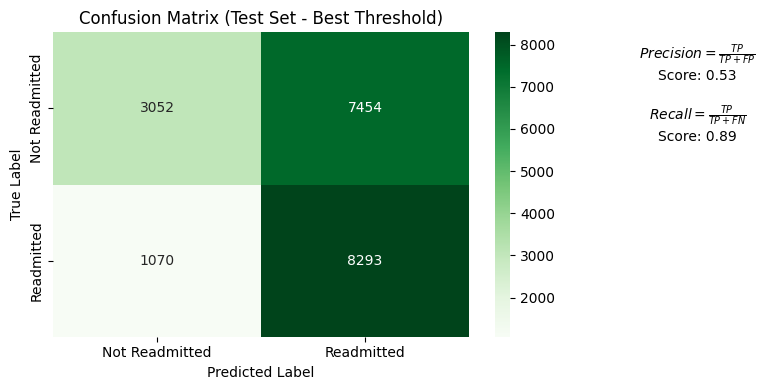

In [30]:
# Generate predictions on test set
print('Generating predictions on test data...')
ypred_test_proba = model_finetuned.predict(test_inputs).ravel()

# use the default threshold: 0.5
ypred_test_binary_default = (ypred_test_proba >= default_threshold).astype(int).flatten()

# Convert to binary predictions using the validation-selected threshold.
ypred_test_binary = (ypred_test_proba >= best_threshold).astype(int).flatten()

print(f'Test set size: {len(y_test)} samples')
print(f'Predictions generated: {len(ypred_test_binary)}')
print(f'Classification threshold before calibration: {default_threshold:.3f}')
print(f'Classification threshold after calibration: {best_threshold:.3f}')
print('-------')


print('Classification Report using the default (0.5) threshold:')
# Classification Report:
recall_test, precision_test, f1_test, acc_test, cl_report_test = (
    evaluate_predictions(true_values=y_test,
                         predictions= ypred_test_binary_default,
                         print_class_report=True)
)

# confusion matrix
scores_test = plot_confusion_matrix(y_true=y_test['readmitted'],
                                    y_pred= ypred_test_binary_default,
                                    fig_size=(8, 4),
                                    class_names=['Not Readmitted', 'Readmitted'],
                                    title='Confusion Matrix (Test Set - Default Threshold of 0.5)',
                                    colour_map='Greens')

#############
print('Classification Report using the best threshold:')
# Classification Report:
recall_test, precision_test, f1_test, acc_test, cl_report_test = (
    evaluate_predictions(true_values=y_test,
                         predictions=ypred_test_binary,
                         print_class_report=True)
)

# confusion matrix
scores_test = plot_confusion_matrix(y_true=y_test['readmitted'],
                                    y_pred=ypred_test_binary,
                                    fig_size=(8, 4),
                                    class_names=['Not Readmitted', 'Readmitted'],
                                    title='Confusion Matrix (Test Set - Best Threshold)',
                                    colour_map='Greens')

In [31]:
# Summarising evaluation metrics
print()
print('-' * 30)
print('TEST SET PERFORMANCE SUMMARY')
print('-' * 30)
print(f'Threshold: {best_threshold:.3f}')
print(f'Accuracy:  {acc_test:.4f}')
print(f'Recall:    {recall_test:.4f}')
print(f'Precision: {precision_test:.4f}')
print(f'F1-Score:  {f1_test:.4f}')
print('-' * 30)
print()

# storing results for comparison
test_results = {
    'dataset': 'test',
    'n_samples': len(y_test),
    'threshold': best_threshold,
    'accuracy': acc_test,
    'recall': recall_test,
    'precision': precision_test,
    'f1_score': f1_test,
    'confusion_matrix': scores_test['confusion_matrix']
}



------------------------------
TEST SET PERFORMANCE SUMMARY
------------------------------
Threshold: 0.435
Accuracy:  0.5710
Recall:    0.8857
Precision: 0.5266
F1-Score:  0.6605
------------------------------



In [32]:
test_results

{'dataset': 'test',
 'n_samples': 19869,
 'threshold': 0.43499999999999994,
 'accuracy': 0.5709899843978056,
 'recall': 0.8857203887642849,
 'precision': 0.5266399949196673,
 'f1_score': 0.6605336519315014,
 'confusion_matrix': array([[3052, 7454],
        [1070, 8293]])}

**Saving the model:**

In [33]:
MODEL_NAME = 'logistic_regression_tf_SGD'
MODEL_PATH = export_dir / f"{MODEL_NAME}_finetuned.keras"
model_finetuned.save(MODEL_PATH)

# Save the Optuna trial history for later comparison.
optuna_trials_path = export_dir / f"{MODEL_NAME}_optuna_trials.csv"
study.trials_dataframe().to_csv(optuna_trials_path, index=False)

# Save the best hyperparameters as a readable JSON file.
best_params_path = export_dir / f"{MODEL_NAME}_best_params.json"
with open(best_params_path, 'w') as f:
    json.dump(best_params, f, indent=2)

# Save all validation thresholds so the chosen threshold can be audited later.
threshold_results_path = export_dir / f"{MODEL_NAME}_threshold_results.csv"
threshold_results.to_csv(threshold_results_path, index=False)

# Convert NumPy values to plain Python values before writing JSON.
test_results_to_save = {
    key: (value.tolist() if hasattr(value, 'tolist') else value)
    for key, value in test_results.items()
}

test_results_path = export_dir / f"{MODEL_NAME}_test_results.json"
with open(test_results_path, 'w') as f:
    json.dump(test_results_to_save, f, indent= 2)

print(f"Model saved to: {MODEL_PATH.resolve()}")
print(f"Optuna trials saved to: {optuna_trials_path.resolve()}")
print(f"Best parameters saved to: {best_params_path.resolve()}")
print(f"Threshold results saved to: {threshold_results_path.resolve()}")
print(f"Test results saved to: {test_results_path.resolve()}")

Model saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/logistic_regression_tf_SGD/logistic_regression_tf_SGD_finetuned.keras
Optuna trials saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/logistic_regression_tf_SGD/logistic_regression_tf_SGD_optuna_trials.csv
Best parameters saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/logistic_regression_tf_SGD/logistic_regression_tf_SGD_best_params.json
Threshold results saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/logistic_regression_tf_SGD/logistic_regression_tf_SGD_threshold_results.csv
Test results saved to: /Users/vtsoumpris/PycharmProjects/ds207_final_project/models/logistic_regression_tf_SGD/logistic_regression_tf_SGD_test_results.json
